In [1]:
%load_ext autoreload
%autoreload 2


In [7]:
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *

In [3]:
all_df = pd.read_parquet("residual_datasets/all_ds_perf.parquet")
large_df = pd.read_parquet("residual_datasets/large_ds_perf.parquet")
common_perts = set(all_df["perturbation"].unique()).intersection(set(large_df["perturbation"].unique()))

In [4]:
# from results_analysis_helper import *

# folder = Path("/cwork/hl489/Pertb_benchmark/DataSet2")
# keywords = ["K562", "HEK293T", "HCT116"]

# dfs = []
# for f in sorted(folder.glob("*_hvg5000.tsv")):
#     if any(k in f.name for k in keywords):
#         df = pd.read_csv(f, sep="\t")
#         df["source_file"] = f.name
#         dfs.append(df)

# df1 = pd.concat(dfs, ignore_index=True)
# df1.drop(columns=["source_file"], inplace=True)

# df = pd.read_csv("/cwork/hl489/Pertb_benchmark/DataSet2/performance_jurkat_rpe1_hepg2_hvg5000.tsv", sep='\t')
# # df = df[df.metric != "wasserstein"]
# # df.drop(columns=["split"], inplace=True)
# df.columns
# df.metric.unique()

# df = pd.concat([df, df1], ignore_index=True)

# cell_types = "all"
# # cell_types = ["K562", "HCT116", "HEK293T"] # "K562", "HCT116", "HEK293T", "hepg2", "jurkat", "rpe1"
# if cell_types != "all":
#     df = df[df.DataSet.isin(cell_types)]

# cell_types_joined = "_".join(cell_types) if isinstance(cell_types, list) else cell_types
# # Additional Filters



# df = df[(df.DEG == 5000) & (df.method != "controlMean")]

# # Rename existing metrics for consistency
# df['metric'] = df['metric'].replace({
#     'pearson_distance': 'pearson_distance_delta',
#     'spearman_distance': 'spearman_distance_raw',
# })




In [ ]:
# Load gene_perf from both parquet groups and concat
_geneperf_groups = ["K562_HCT116_HEK293T", "hepg2_jurkat_rpe1"]
gene_perf = pd.concat([
    pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_{g}_hvg5000_detail.parquet")
    for g in _geneperf_groups
], ignore_index=True)
# if cell_types != "all":
#     gene_perf = gene_perf[gene_perf['dataset'].isin(cell_types)]

In [5]:
# gene_perf_HEK293T = pd.read_parquet("/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_HEK293T_hvg5000_trainMeanfull_s5to9_allgenes_detail.parquet")
# gene_perf_HCT116 = pd.read_parquet("/cwork/hl489/Pertb_benchmark/DataSet2/geneperf_HCT116_hvg5000_trainMeanfull_s5to9_allgenes_detail.parquet")
# gene_perf_HCT116.columns
# gene_perf_HCT116.method.value_counts()
# m = "trainMean_full_noMatch"
# gene_perf = pd.concat([gene_perf_HEK293T[gene_perf_HEK293T.method == m], gene_perf_HCT116[gene_perf_HCT116.method == m]])
# gene_perf = gene_perf[gene_perf.perturbation.isin(common_perts)]
# gene_perf = gene_perf.rename(columns={"Dataset": "dataset"})

In [8]:
new_metrics = compute_new_corr_metrics(
    gene_perf[gene_perf['method'] != 'controlMean'],
    deg=[1000, 2000, 5000],
    sign_tau=0.0,
    updown_tau=0.0,
    de_frac=0.1,
    topk_values=(100,),
    include_metrics=('pearson', 'spearman'),
)




# df = pd.concat([df, new_metrics], ignore_index=True)


Computed from gene_perf (DEG levels=[1000, 2000, 5000])
  include_metrics=['pearson_distance_delta', 'pearson_distance_raw', 'spearman_distance_delta', 'spearman_distance_raw']
  sign_tau=0.0, updown_tau=0.0, de_frac=0.1, topk_values=[100]
  pearson_distance_raw:    43425 entries  (skipped 27 due to zero std)
  spearman_distance_raw:   43425 entries  (skipped 27 due to zero std)
  pearson_distance_delta:  43452 entries  (skipped 0 due to zero std)
  spearman_distance_delta: 43452 entries  (skipped 0 due to zero std)


In [11]:
method_performance_overview(
    new_metrics[new_metrics.DEG == 5000],
    common_only=True,
    convert_higher_to_lower=True,   # flips ccc_delta to distance
)


No rows found for metrics marked as higher-is-better: ['ccc_delta']
Filtered to 284 common perturbations across ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']

0. NUMBER OF PERTURBATIONS PER METHOD x CELL LINE
DataSet    HCT116  HEK293T  K562  hepg2  jurkat  rpe1
method                                               
CPA           284      284   284    284     284   284
GEARS         284      284   284    284     284   284
scGPT         284      284   284    284     284   284
trainMean     284      284   284    284     284   284

1. OVERALL MEAN PERFORMANCE (lower = better)
method
trainMean    0.3794
scGPT        0.4283
GEARS        0.4607
CPA          0.4776

2. METHOD x CELL LINE (avg across metric, DEG)
DataSet    HCT116  HEK293T    K562   hepg2  jurkat    rpe1    mean
method                                                            
trainMean  0.4228   0.4288  0.3856  0.3729  0.3905  0.2759  0.3794
scGPT      0.4828   0.4944  0.4614  0.3997  0.4324  0.2992  0.4283
GEARS  

{'overall': method
 trainMean    0.379424
 scGPT        0.428320
 GEARS        0.460680
 CPA          0.477648
 Name: performance, dtype: float64,
 'method_cellline': DataSet      HCT116   HEK293T      K562     hepg2    jurkat      rpe1  \
 method                                                                  
 trainMean  0.422806  0.428830  0.385569  0.372874  0.390530  0.275936   
 scGPT      0.482797  0.494405  0.461427  0.399733  0.432393  0.299168   
 GEARS      0.505883  0.500613  0.492437  0.460444  0.455450  0.349252   
 CPA        0.473961  0.464368  0.495430  0.467229  0.487120  0.477779   
 
 DataSet        mean  
 method               
 trainMean  0.379424  
 scGPT      0.428320  
 GEARS      0.460680  
 CPA        0.477648  ,
 'method_metric': metric     pearson_distance_delta  pearson_distance_raw  \
 method                                                    
 CPA                      0.923280              0.006602   
 GEARS                    0.852009              0.02

In [39]:
pivot = perturbation_analysis(new_metrics, method="trainMean", metric="spearman_distance_delta", deg=2000, top_n=20, agg_func='mean')

Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Lower = better | n=284 common perturbations

TOP 20 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ELL      0.5635   0.6089  0.5140  0.2814  0.2706  0.0570     0.3826
GTF2E2   0.8526   0.5700  0.3800  0.2575  0.2270  0.1308     0.4030
POLR2H   0.3669   0.5066  0.4998  0.2256  0.6072  0.2464     0.4088
MCM3     0.5634   0.5972  0.4622  0.2905  0.5363  0.0805     0.4217
CSE1L    0.5479   0.5922  0.4583  0.3336  0.4674  0.1327     0.4220
ERCC2    0.6123   0.5208  0.3381  0.5444  0.3297  0.2050     0.4250
POLR2A   0.4745   0.5385  0.4272  0.1941  0.4652  0.4514     0.4252
PAF1     0.6901   0.6108  0.5171  0.1994  0.3593  0.2030     0.43

In [40]:
from scipy.stats import spearmanr, kendalltau
import itertools

cell_lines = ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
mat = pivot[cell_lines].dropna()

# --- Pairwise Spearman correlations ---
rows = []
for a, b in itertools.combinations(cell_lines, 2):
    rho, p = spearmanr(mat[a], mat[b])
    rows.append({'cell_line_1': a, 'cell_line_2': b, 'rho': round(rho, 4), 'p': p})

pairwise = pd.DataFrame(rows)
print("Pairwise Spearman correlations (n={} perturbations)".format(len(mat)))
print(pairwise.to_string(index=False))

# Compact matrix view
rho_mat = pd.DataFrame(np.ones((len(cell_lines), len(cell_lines))),
                        index=cell_lines, columns=cell_lines)
for _, r in pairwise.iterrows():
    rho_mat.loc[r['cell_line_1'], r['cell_line_2']] = r['rho']
    rho_mat.loc[r['cell_line_2'], r['cell_line_1']] = r['rho']
print("\nCorrelation matrix:")
print(rho_mat.round(4).to_string())

# --- Kendall's W ---
# Rank each cell line independently, then compute W
ranks = mat[cell_lines].rank(axis=0)  # rank perturbations within each cell line
n = len(ranks)       # number of perturbations (items)
k = len(cell_lines)  # number of raters (cell lines)
rank_sums = ranks.sum(axis=1)
S = ((rank_sums - rank_sums.mean()) ** 2).sum()
W = 12 * S / (k**2 * (n**3 - n))
print(f"\nKendall's W = {W:.4f}  (k={k} raters, n={n} items)")


Pairwise Spearman correlations (n=284 perturbations)
cell_line_1 cell_line_2    rho            p
     HCT116     HEK293T 0.4320 2.444980e-14
     HCT116        K562 0.2369 5.537662e-05
     HCT116       hepg2 0.3355 6.741059e-09
     HCT116      jurkat 0.1402 1.804526e-02
     HCT116        rpe1 0.3204 3.360250e-08
    HEK293T        K562 0.3278 1.548299e-08
    HEK293T       hepg2 0.2162 2.422833e-04
    HEK293T      jurkat 0.2645 6.238247e-06
    HEK293T        rpe1 0.1539 9.393872e-03
       K562       hepg2 0.3444 2.486498e-09
       K562      jurkat 0.3851 1.782308e-11
       K562        rpe1 0.2620 7.638226e-06
      hepg2      jurkat 0.2506 1.922834e-05
      hepg2        rpe1 0.5791 7.787456e-27
     jurkat        rpe1 0.2157 2.495697e-04

Correlation matrix:
         HCT116  HEK293T    K562   hepg2  jurkat    rpe1
HCT116   1.0000   0.4320  0.2369  0.3355  0.1402  0.3204
HEK293T  0.4320   1.0000  0.3278  0.2162  0.2645  0.1539
K562     0.2369   0.3278  1.0000  0.3444  0.3851  0

In [14]:
gene_perf[gene_perf.method == "trainMean"].groupby("dataset").deg_rank.describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
HCT116,5029905.0,2798.0,1615.137513,1.0,1399.00,2798.0,4197.00,5595.0
HEK293T,5089749.0,2825.0,1630.725970,1.0,1413.00,2825.0,4237.00,5649.0
K562,4724844.0,2622.5,1513.812538,1.0,1311.75,2622.5,3933.25,5244.0
hepg2,1600840.0,2582.5,1490.718833,1.0,1291.75,2582.5,3873.25,5164.0
jurkat,1609446.0,2571.5,1484.367975,1.0,1286.00,2571.5,3857.00,5142.0
rpe1,1524204.0,2566.5,1481.481249,1.0,1283.75,2566.5,3849.25,5132.0


In [15]:
gene_perf = gene_perf[gene_perf.perturbation.isin(common_perts)]

In [16]:
gene_perf.perturbation.nunique()

284

In [16]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

# ----------------------------
# 1) Build perturbation features per dataset
# ----------------------------
results_all = []

for c in gene_perf['dataset'].dropna().unique():
    df_temp = gene_perf[
        (gene_perf['dataset'] == c)
        & (gene_perf['method'] == 'trainMean')
        & (gene_perf['deg_rank'] <= 10000)
    ].copy()

    avg = (
        df_temp.groupby(['perturbation', 'gene'], as_index=False)
        .agg(true_delta=('mean_true_delta', 'mean'))
    )

    delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
    gene_effect = delta_matrix.mean(axis=1)

    records = []
    for pert in delta_matrix.columns:
        col = delta_matrix[pert].dropna()
        gene_eff = gene_effect.loc[col.index]

        effect_size = col.abs().mean()
        residual = col - gene_eff
        total_var = col.var()
        resid_var = residual.var()
        specificity = resid_var / total_var if total_var > 0 else np.nan

        records.append({
            'dataset': c,
            'perturbation': pert,
            'effect_size': effect_size,
            'specificity': specificity,
            'total_var': total_var,
            'gene_effect_var': (total_var - resid_var),
        })

    results_all.append(pd.DataFrame(records))

pert_features = pd.concat(results_all, ignore_index=True)

# ----------------------------
# 2) Build dataset-specific mean_perf from existing pivot
#    (pivot is wide: one column per dataset)
# ----------------------------
cell_types = [d for d in gene_perf['dataset'].dropna().unique() if d in pivot.columns]
if not cell_types:
    raise ValueError("No dataset columns from gene_perf were found in pivot.")

pivot_df = pivot.reset_index()
perturb_col = 'perturb' if 'perturb' in pivot_df.columns else pivot_df.columns[0]

perf_by_ds = (
    pivot_df[[perturb_col] + cell_types]
    .melt(id_vars=perturb_col, var_name='dataset', value_name='mean_perf')
    .rename(columns={perturb_col: 'perturbation'})
    .dropna(subset=['mean_perf'])
)

# Merge on BOTH keys so no cross-dataset averaging
pert_features = pert_features.merge(
    perf_by_ds,
    on=['dataset', 'perturbation'],
    how='inner'
)

# ----------------------------
# 3) Spearman correlations per dataset (no plotting)
# ----------------------------
features = ['effect_size', 'specificity', 'total_var']
rows = []

for ds, sub in pert_features.groupby('dataset'):
    for feat in features:
        vals = sub[[feat, 'mean_perf']].dropna()

        if len(vals) < 3 or vals[feat].nunique() < 2 or vals['mean_perf'].nunique() < 2:
            rho, p = np.nan, np.nan
        else:
            rho, p = spearmanr(vals[feat], vals['mean_perf'])

        rows.append({
            'dataset': ds,
            'feature': feat,
            'rho': rho,
            'p': p,
            'n_perturbations': len(vals),
        })

corr_by_dataset = pd.DataFrame(rows).sort_values(['dataset', 'feature'])

print("Per-dataset Spearman correlations with prediction error:")
print(corr_by_dataset.to_string(index=False))

# Optional compact rho table
rho_table = corr_by_dataset.pivot(index='dataset', columns='feature', values='rho')
print("\nRho table:")
print(rho_table.round(4).to_string())


Per-dataset Spearman correlations with prediction error:
dataset     feature       rho             p  n_perturbations
 HCT116 effect_size -0.250573  1.933312e-05              284
 HCT116 specificity  0.760494  8.173678e-55              284
 HCT116   total_var -0.262523  7.343459e-06              284
HEK293T effect_size -0.044252  4.575898e-01              284
HEK293T specificity  0.681072  4.675612e-40              284
HEK293T   total_var -0.063119  2.891169e-01              284
   K562 effect_size -0.364783  2.295779e-10              284
   K562 specificity  0.855255  1.713211e-82              284
   K562   total_var -0.380977  3.047161e-11              284
  hepg2 effect_size -0.568824  9.562650e-26              284
  hepg2 specificity  0.942086 7.954919e-136              284
  hepg2   total_var -0.631501  5.201013e-33              284
 jurkat effect_size -0.467791  7.556471e-17              284
 jurkat specificity  0.936833 1.131575e-130              284
 jurkat   total_var -0.53009

In [57]:
import numpy as np
import pandas as pd

# =========================================================
# A) Per-dataset/per-perturbation specificity + bootstrap SE
# =========================================================
def compute_specificity_with_bootstrap(
    gene_perf,
    method='trainMean',
    max_deg=10000,
    n_boot=200,          # increase to 500+ for more stable SEs
    random_state=0,
    min_boot_ok=30
):
    rng = np.random.default_rng(random_state)
    rows = []

    datasets = gene_perf['dataset'].dropna().unique()

    for ds in datasets:
        df_temp = gene_perf[
            (gene_perf['dataset'] == ds) &
            (gene_perf['method'] == method) &
            (gene_perf['deg_rank'] <= max_deg)
        ].copy()

        if df_temp.empty:
            continue

        avg = (
            df_temp.groupby(['perturbation', 'gene'], as_index=False)
            .agg(true_delta=('mean_true_delta', 'mean'))
        )

        delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
        gene_effect = delta_matrix.mean(axis=1)

        for pert in delta_matrix.columns:
            col = delta_matrix[pert].dropna()
            if len(col) < 3:
                continue

            gene_eff = gene_effect.loc[col.index]
            x = col.to_numpy(dtype=float)
            g = gene_eff.to_numpy(dtype=float)

            total_var = np.var(x, ddof=1)
            if not np.isfinite(total_var) or total_var <= 0:
                rows.append({
                    'dataset': ds,
                    'perturbation': pert,
                    'specificity': np.nan,
                    'log_specificity': np.nan,
                    'se_log_specificity': np.nan,
                    'n_genes': len(x),
                    'n_boot_ok': 0
                })
                continue

            resid_var = np.var(x - g, ddof=1)
            specificity = resid_var / total_var
            log_spec = np.log(specificity) if np.isfinite(specificity) and specificity > 0 else np.nan

            # bootstrap SE for log(specificity)
            boot_logs = []
            n = len(x)
            for _ in range(n_boot):
                idx = rng.integers(0, n, size=n)  # resample genes with replacement
                xb = x[idx]
                gb = g[idx]

                vxb = np.var(xb, ddof=1)
                if not np.isfinite(vxb) or vxb <= 0:
                    continue

                sb = np.var(xb - gb, ddof=1) / vxb
                if np.isfinite(sb) and sb > 0:
                    boot_logs.append(np.log(sb))

            boot_logs = np.asarray(boot_logs, dtype=float)
            se_log = np.std(boot_logs, ddof=1) if len(boot_logs) >= 2 else np.nan

            if len(boot_logs) < min_boot_ok:
                se_log = np.nan

            rows.append({
                'dataset': ds,
                'perturbation': pert,
                'specificity': specificity,
                'log_specificity': log_spec,
                'se_log_specificity': se_log,
                'n_genes': n,
                'n_boot_ok': len(boot_logs)
            })

    return pd.DataFrame(rows)


# =========================================================
# B) Random-effects meta-analysis across datasets (per perturbation)
# =========================================================
def random_effects_pool(log_vals, se_vals):
    y = np.asarray(log_vals, dtype=float)
    se = np.asarray(se_vals, dtype=float)

    m = np.isfinite(y) & np.isfinite(se) & (se > 0)
    y = y[m]
    se = se[m]

    k = len(y)
    if k == 0:
        return None

    v = se**2

    if k == 1:
        mu = y[0]
        se_mu = se[0]
        tau2 = 0.0
        Q = np.nan
        I2 = np.nan
    else:
        w = 1.0 / v
        mu_fe = np.sum(w * y) / np.sum(w)
        Q = np.sum(w * (y - mu_fe) ** 2)
        C = np.sum(w) - (np.sum(w**2) / np.sum(w))
        tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

        w_re = 1.0 / (v + tau2)
        mu = np.sum(w_re * y) / np.sum(w_re)
        se_mu = np.sqrt(1.0 / np.sum(w_re))
        I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0

    return {
        'mu_log': mu,
        'se_mu_log': se_mu,
        'tau2': tau2,
        'Q': Q,
        'I2_percent': I2,
        'k_used': k
    }


def compute_global_specificity(spec_boot_df):
    out = []

    for pert, g in spec_boot_df.groupby('perturbation'):
        pooled = random_effects_pool(g['log_specificity'], g['se_log_specificity'])
        if pooled is None:
            continue

        mu = pooled['mu_log']
        se_mu = pooled['se_mu_log']

        out.append({
            'perturbation': pert,
            'global_specificity': np.exp(mu),
            'ci_low_95': np.exp(mu - 1.96 * se_mu),
            'ci_high_95': np.exp(mu + 1.96 * se_mu),
            'k_celltypes_used': pooled['k_used'],
            'tau2': pooled['tau2'],
            'I2_percent': pooled['I2_percent']
        })

    return pd.DataFrame(out).sort_values('global_specificity', ascending=False)


# =========================================================
# C) Run
# =========================================================
spec_boot = compute_specificity_with_bootstrap(
    gene_perf,
    method='trainMean',
    max_deg=10000,
    n_boot=500,
    random_state=0
)

global_specificity = compute_global_specificity(spec_boot)

# print("Per-dataset specificity with bootstrap SE:")
# print(spec_boot.head().to_string(index=False))

# print("\nGlobal (across cell types) specificity per perturbation:")
# print(global_specificity.head(20).to_string(index=False))


(array([50., 99., 47., 33., 19., 18., 10.,  5.,  1.,  2.]),
 array([0.6298024 , 0.77143957, 0.91307675, 1.05471392, 1.1963511 ,
        1.33798827, 1.47962545, 1.62126262, 1.7628998 , 1.90453697,
        2.04617415]),
 <BarContainer object of 10 artists>)

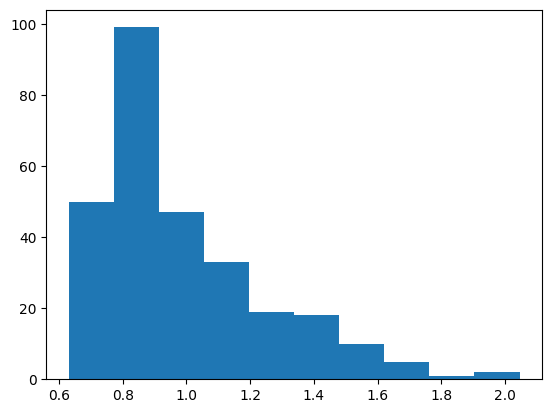

In [58]:
plt.hist(global_specificity.global_specificity, bins=10)

(array([50., 99., 47., 33., 19., 18., 10.,  5.,  1.,  2.]),
 array([0.63003883, 0.77164635, 0.91325388, 1.05486141, 1.19646893,
        1.33807646, 1.47968399, 1.62129151, 1.76289904, 1.90450656,
        2.04611409]),
 <BarContainer object of 10 artists>)

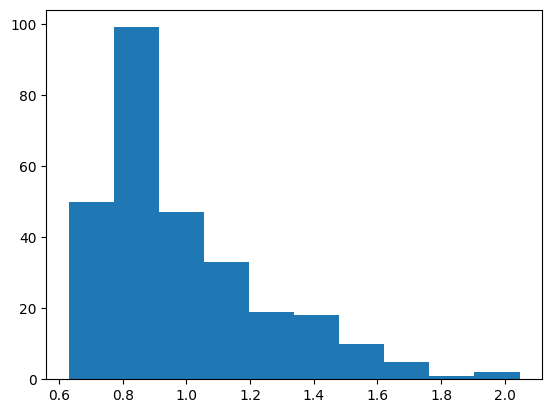

In [22]:
plt.hist(global_specificity.global_specificity, bins=10)

Spearman(global_specificity, median_perf): rho=0.8499, p=1.95e-80, n=284


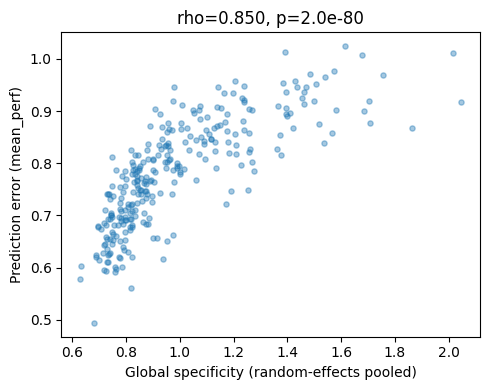

In [23]:
from scipy.stats import spearmanr
import pandas as pd
import matplotlib.pyplot as plt

perf_col = "median_perf"   # or "median_perf"

pivot_perf = (
    pivot.reset_index()[['perturb', perf_col]]
    .rename(columns={'perturb': 'perturbation'})
)

plot_df = (
    global_specificity[['perturbation', 'global_specificity']]
    .merge(pivot_perf, on='perturbation', how='inner')
    .dropna(subset=['global_specificity', perf_col])
)

rho, p = spearmanr(plot_df['global_specificity'], plot_df[perf_col])
print(f"Spearman(global_specificity, {perf_col}): rho={rho:.4f}, p={p:.2e}, n={len(plot_df)}")


plt.figure(figsize=(5,4))
plt.scatter(plot_df['global_specificity'], plot_df[perf_col], alpha=0.4, s=14)
plt.xlabel('Global specificity (random-effects pooled)')
plt.ylabel('Prediction error (mean_perf)')
plt.title(f'rho={rho:.3f}, p={p:.1e}')
plt.tight_layout()
plt.show()


In [42]:
new_metrics

,DataSet,method,split,perturb,DEG,Nstimulated,Nimputed,metric,performance
0,HCT116,CPA,5,AATF,1000,34,34,pearson_distance_raw,0.0018
1,HCT116,CPA,5,AATF,1000,34,34,spearman_distance_raw,0.3584
2,HCT116,CPA,5,AATF,1000,34,34,pearson_distance_delta,0.9227
3,HCT116,CPA,5,AATF,1000,34,34,spearman_distance_delta,0.9580
4,HCT116,CPA,5,AATF,2000,34,34,pearson_distance_raw,0.0033
...,...,...,...,...,...,...,...,...,...
173749,rpe1,trainMean,4,ZNF24,2000,49,49,spearman_distance_delta,0.9749
173750,rpe1,trainMean,4,ZNF24,5000,49,49,pearson_distance_raw,0.0103
173751,rpe1,trainMean,4,ZNF24,5000,49,49,spearman_distance_raw,0.0604
173752,rpe1,trainMean,4,ZNF24,5000,49,49,pearson_distance_delta,0.9946


Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  71 shared perturbations across 6 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=-0.088 (p=7.12e-02, n=426)
           CPA vs scGPT       : rho=-0.030 (p=5.39e-01, n=426)
           CPA vs trainMean   : rho=-0.079 (p=1.05e-01, n=426)
         GEARS vs scGPT       : rho=0.677 (p=2.01e-58, n=426)
         GEARS vs trainMean   : rho=0.661 (p=8.60e-55, n=426)
         scGPT vs trainMean   : rho=0.712 (p=5.39e-67, n=426)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  238  (55.9%)
           CPA:  125  (29.3%)
         scGPT:   41  (9.6%)
         GEARS:   22  (5.2%)

Median spearman_distance_delta (lower is better):
              CPA: 0.9636
            GEARS: 0.9689
            scGPT: 0.9330
        trainMean: 0.8922
      oracle_best: 0.8545

Wilcoxon signed-rank test (oracle_best vs each method):
  ora

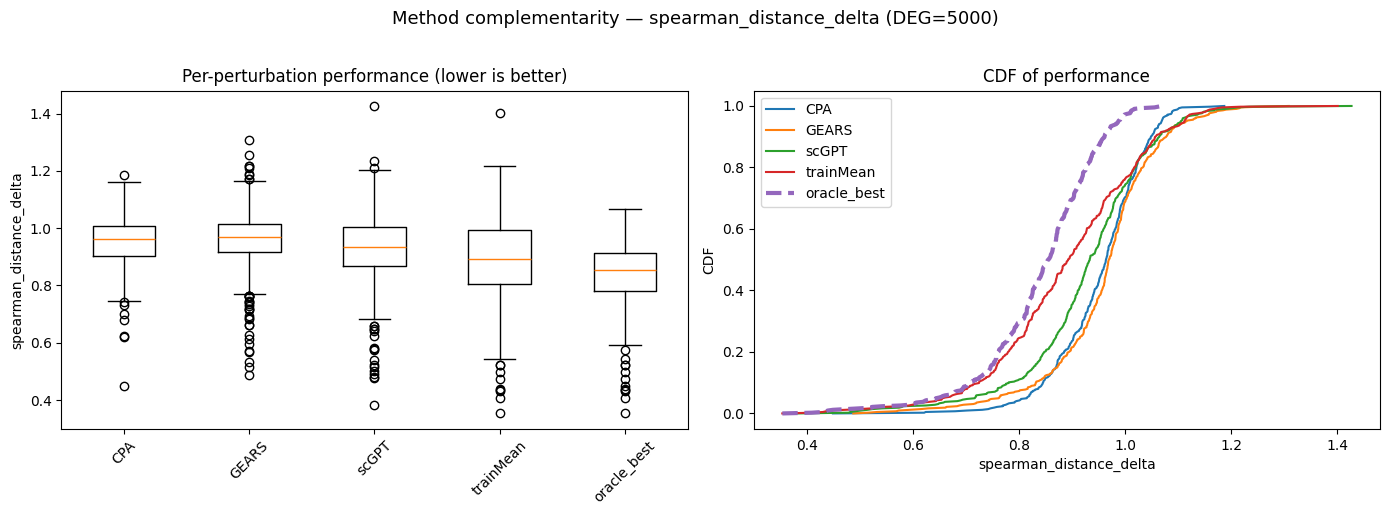

In [56]:
from results_modeling_helper import method_complementarity
pivot_all = method_complementarity(
    new_metrics[new_metrics.perturb.isin(top_quarter_perts)], metric="spearman_distance_delta", deg=5000, baseline="trainMean"
)



################################################################################
DataSet: HCT116
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  899 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=-0.039 (p=2.44e-01, n=899)
           CPA vs scGPT       : rho=-0.014 (p=6.71e-01, n=899)
           CPA vs trainMean   : rho=0.001 (p=9.88e-01, n=899)
         GEARS vs scGPT       : rho=0.110 (p=9.62e-04, n=899)
         GEARS vs trainMean   : rho=0.181 (p=4.60e-08, n=899)
         scGPT vs trainMean   : rho=0.459 (p=3.74e-48, n=899)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  503  (56.0%)
           CPA:  265  (29.5%)
         scGPT:   81  (9.0%)
         GEARS:   50  (5.6%)

Median spearman_distance_delta (lower is better):
             

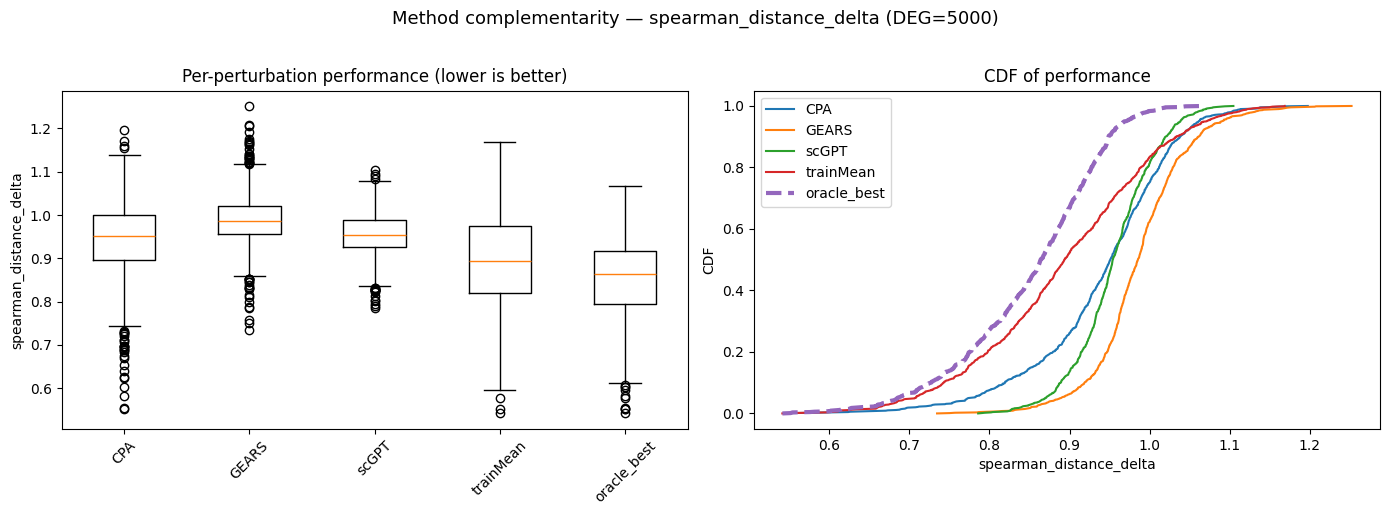


################################################################################
DataSet: HEK293T
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  901 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=0.009 (p=7.76e-01, n=901)
           CPA vs scGPT       : rho=0.020 (p=5.47e-01, n=901)
           CPA vs trainMean   : rho=-0.035 (p=2.94e-01, n=901)
         GEARS vs scGPT       : rho=0.044 (p=1.89e-01, n=901)
         GEARS vs trainMean   : rho=0.079 (p=1.70e-02, n=901)
         scGPT vs trainMean   : rho=-0.403 (p=1.84e-36, n=901)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  427  (47.4%)
           CPA:  215  (23.9%)
         scGPT:  178  (19.8%)
         GEARS:   81  (9.0%)

Median spearman_distance_delta (lower is better):
           

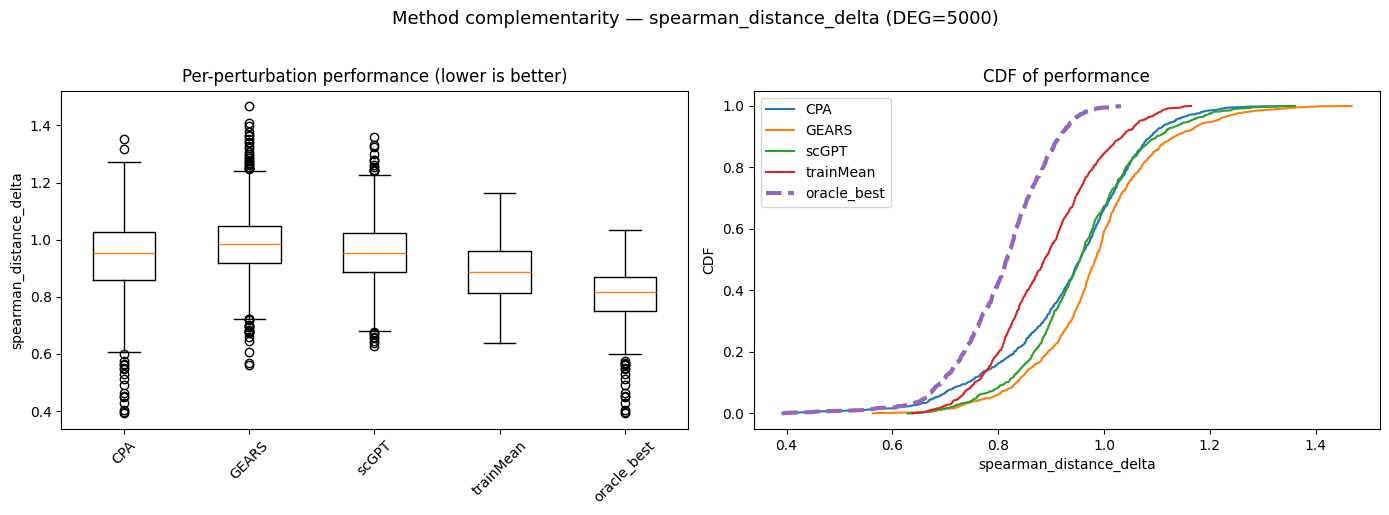


################################################################################
DataSet: K562
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  901 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=0.000 (p=9.94e-01, n=901)
           CPA vs scGPT       : rho=0.045 (p=1.74e-01, n=901)
           CPA vs trainMean   : rho=0.014 (p=6.85e-01, n=901)
         GEARS vs scGPT       : rho=0.539 (p=4.58e-69, n=901)
         GEARS vs trainMean   : rho=0.636 (p=4.02e-103, n=901)
         scGPT vs trainMean   : rho=0.884 (p=1.73e-298, n=901)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  757  (84.0%)
           CPA:  102  (11.3%)
         scGPT:   29  (3.2%)
         GEARS:   13  (1.4%)

Median spearman_distance_delta (lower is better):
              C

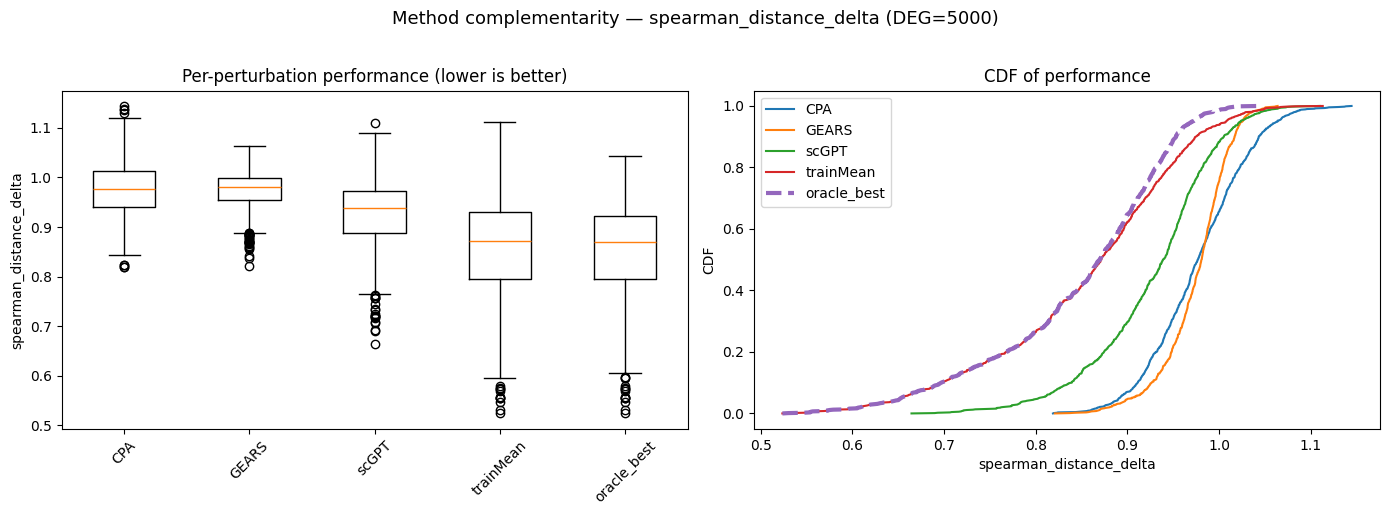


################################################################################
DataSet: hepg2
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  310 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=-0.067 (p=2.37e-01, n=310)
           CPA vs scGPT       : rho=-0.021 (p=7.13e-01, n=310)
           CPA vs trainMean   : rho=-0.014 (p=8.09e-01, n=310)
         GEARS vs scGPT       : rho=0.806 (p=4.48e-72, n=310)
         GEARS vs trainMean   : rho=0.798 (p=8.40e-70, n=310)
         scGPT vs trainMean   : rho=0.992 (p=1.59e-281, n=310)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  213  (68.7%)
           CPA:   69  (22.3%)
         scGPT:   16  (5.2%)
         GEARS:   12  (3.9%)

Median spearman_distance_delta (lower is better):
            

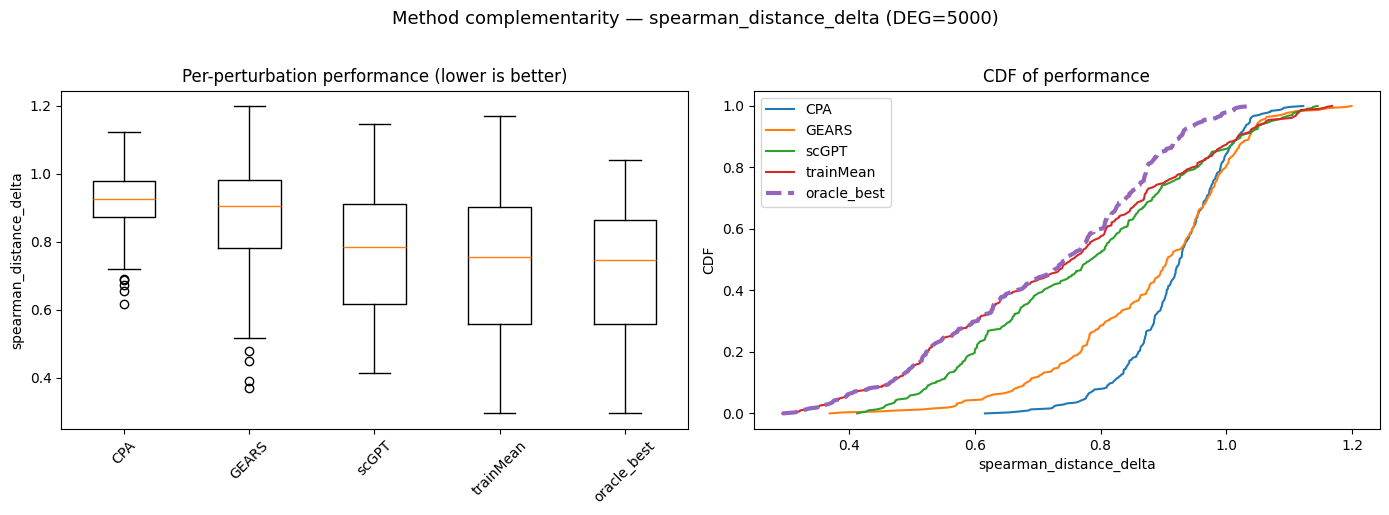


################################################################################
DataSet: jurkat
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  313 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=0.065 (p=2.49e-01, n=313)
           CPA vs scGPT       : rho=0.069 (p=2.24e-01, n=313)
           CPA vs trainMean   : rho=0.075 (p=1.87e-01, n=313)
         GEARS vs scGPT       : rho=0.809 (p=8.95e-74, n=313)
         GEARS vs trainMean   : rho=0.841 (p=5.60e-85, n=313)
         scGPT vs trainMean   : rho=0.969 (p=9.28e-191, n=313)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  261  (83.4%)
           CPA:   30  (9.6%)
         scGPT:   17  (5.4%)
         GEARS:    5  (1.6%)

Median spearman_distance_delta (lower is better):
              C

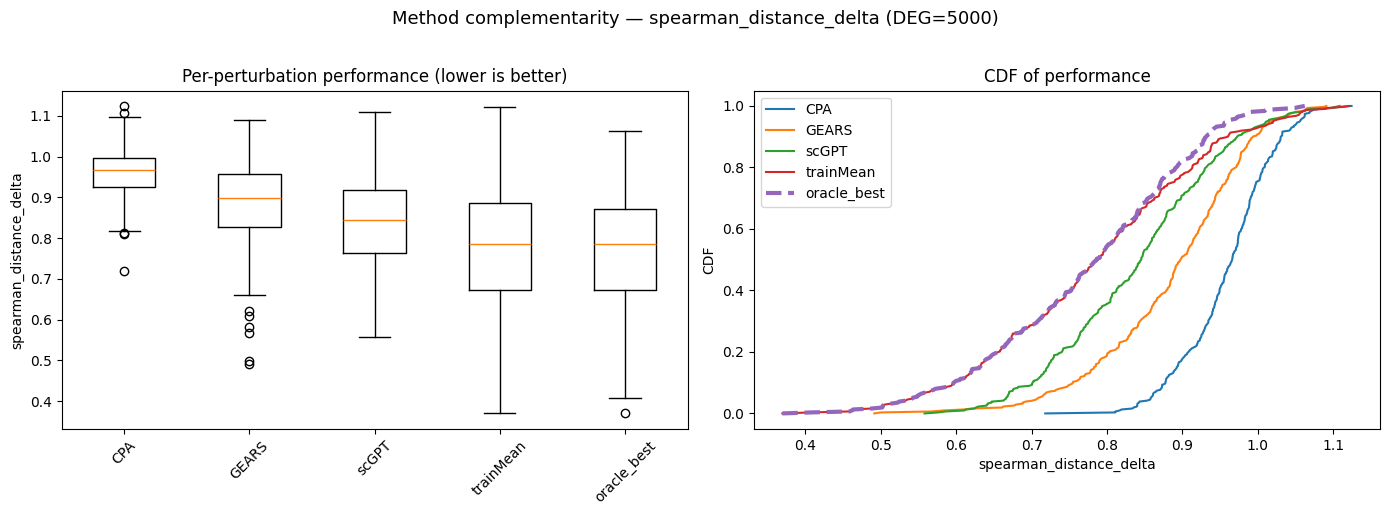


################################################################################
DataSet: rpe1
################################################################################
Method complementarity (spearman_distance_delta, DEG=5000, agg=median)
  297 shared perturbations across 1 cell types

Pairwise Spearman correlation of per-perturbation performance:
           CPA vs GEARS       : rho=0.006 (p=9.23e-01, n=297)
           CPA vs scGPT       : rho=-0.033 (p=5.67e-01, n=297)
           CPA vs trainMean   : rho=-0.024 (p=6.77e-01, n=297)
         GEARS vs scGPT       : rho=0.860 (p=4.59e-88, n=297)
         GEARS vs trainMean   : rho=0.876 (p=1.39e-95, n=297)
         scGPT vs trainMean   : rho=0.993 (p=2.63e-275, n=297)

Oracle best-of ensemble vs individual methods

How often each method is the best:
     trainMean:  249  (83.8%)
           CPA:   31  (10.4%)
         scGPT:   11  (3.7%)
         GEARS:    6  (2.0%)

Median spearman_distance_delta (lower is better):
              

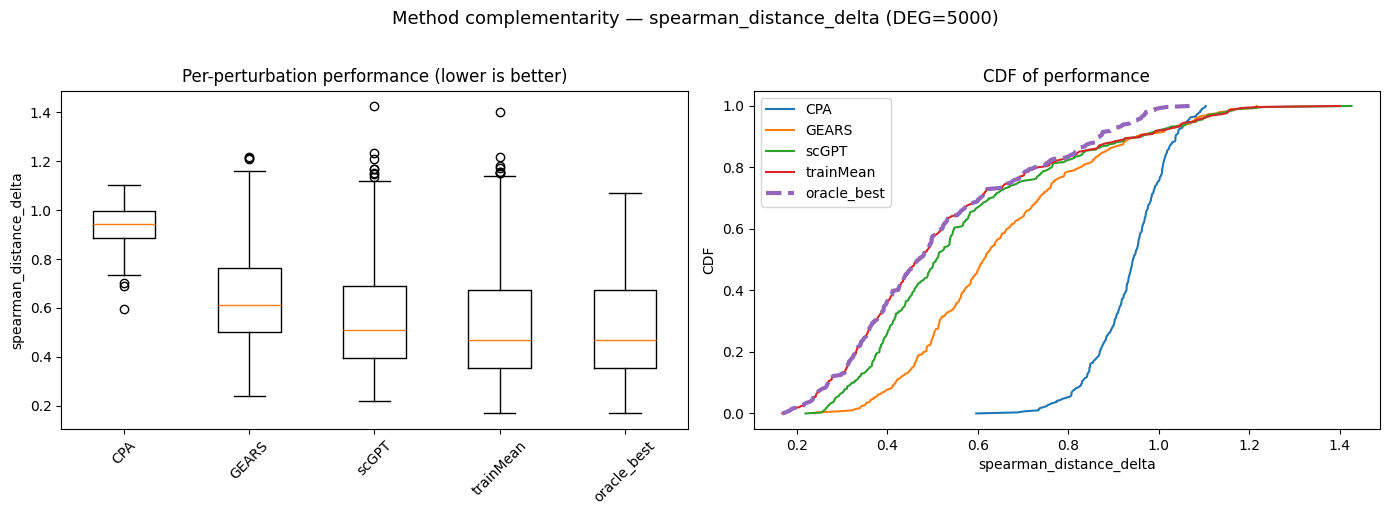

In [27]:
from results_modeling_helper import method_complementarity

# Per-cell-type wrapper
pivot_by_ds = {}
for ds in sorted(new_metrics["DataSet"].dropna().unique()):
    print(f"\n{'#' * 80}")
    print(f"DataSet: {ds}")
    print(f"{'#' * 80}")
    
    sub = new_metrics[new_metrics["DataSet"] == ds].copy()
    if sub.empty:
        print("No rows, skipping.")
        continue

    pivot_by_ds[ds] = method_complementarity(
        sub,
        metric="spearman_distance_delta",
        deg=5000,
        agg_func="median",      # or "mean"
        baseline="trainMean"    # kept for compatibility; currently unused in function
    )

# Optional: inspect one result table
# pivot_by_ds["K562"].head()


In [28]:
summary_rows = []
for ds, p in pivot_by_ds.items():
    m = p[[c for c in p.columns if c not in ["oracle_best", "best_method"]]].median(numeric_only=True)
    row = {"DataSet": ds, **m.to_dict(), "oracle_best": p["oracle_best"].median()}
    summary_rows.append(row)

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("DataSet")
    .sort_index()
)
print(summary_df.round(4).to_string())


            CPA   GEARS   scGPT  trainMean  oracle_best
DataSet                                                
HCT116   0.9508  0.9854  0.9539     0.8933       0.8638
HEK293T  0.9542  0.9834  0.9546     0.8876       0.8163
K562     0.9766  0.9807  0.9390     0.8715       0.8696
hepg2    0.9255  0.9058  0.7844     0.7534       0.7449
jurkat   0.9658  0.8974  0.8454     0.7864       0.7864
rpe1     0.9436  0.6136  0.5088     0.4691       0.4691


In [29]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, mannwhitneyu

# optional (for regression)
import statsmodels.api as sm
import statsmodels.formula.api as smf

# -------------------------------------------------
# Inputs assumed available:
#   1) pivot_all from method_complementarity(...)
#      index: DataSet, perturb
#      columns: methods + oracle_best + best_method
#   2) global_specificity with columns:
#      perturbation, global_specificity
# -------------------------------------------------

eps = 0.0  # set e.g. 0.01 if you want a minimum improvement margin

perf = pivot_all.reset_index().copy()
perf['perturb'] = perf['perturb'].astype(str)

gspec = global_specificity[['perturbation', 'global_specificity']].copy()
gspec['perturbation'] = gspec['perturbation'].astype(str)

# methods that can "correct" trainMean
exclude_cols = {'DataSet', 'perturb', 'trainMean', 'oracle_best', 'best_method'}
other_methods = [c for c in perf.columns if c not in exclude_cols]

if len(other_methods) == 0:
    raise ValueError("No non-trainMean methods found in pivot_all.")

# Row-level correction metrics (row = DataSet x perturb)
perf['best_other'] = perf[other_methods].min(axis=1)
perf['best_improvement'] = perf['trainMean'] - perf['best_other']  # >0 means someone beats trainMean
perf['any_other_better'] = (perf['best_improvement'] > eps).astype(int)
perf['n_other_better'] = perf[other_methods].lt(perf['trainMean'] - eps, axis=0).sum(axis=1)
perf['frac_other_better'] = perf['n_other_better'] / len(other_methods)

# Aggregate to perturbation-level (to match global_specificity level)
pert_level = (
    perf.groupby('perturb', as_index=False)
    .agg(
        p_any_other_better=('any_other_better', 'mean'),
        mean_n_other_better=('n_other_better', 'mean'),
        mean_frac_other_better=('frac_other_better', 'mean'),
        mean_best_improvement=('best_improvement', 'mean'),
        median_best_improvement=('best_improvement', 'median'),
        n_celltypes=('DataSet', 'nunique'),
    )
)

test_df = pert_level.merge(
    gspec, left_on='perturb', right_on='perturbation', how='inner'
).dropna(subset=['global_specificity'])

# 1) Rank-correlation tests
print("Spearman tests vs global_specificity")
for y in [
    'p_any_other_better',
    'mean_n_other_better',
    'mean_frac_other_better',
    'mean_best_improvement',
    'median_best_improvement',
]:
    rho, p = spearmanr(test_df['global_specificity'], test_df[y], nan_policy='omit')
    print(f"{y:26s} rho={rho: .4f}, p={p:.2e}, n={len(test_df)}")

# 2) Top-vs-bottom quartile test
tmp = test_df.copy()
tmp['spec_q'] = pd.qcut(tmp['global_specificity'], 4, labels=['Q1_low', 'Q2', 'Q3', 'Q4_high'])

top = tmp[tmp['spec_q'] == 'Q4_high']
bot = tmp[tmp['spec_q'] == 'Q1_low']

u, p_u = mannwhitneyu(
    top['mean_best_improvement'],
    bot['mean_best_improvement'],
    alternative='greater'  # your directional hypothesis: high specificity has larger improvement
)
print("\nQ4 vs Q1 (mean_best_improvement):")
print(f"n_top={len(top)}, n_bot={len(bot)}, U={u:.1f}, p={p_u:.2e}")

# 3) Optional: row-level logistic regression with dataset fixed effects
# row_df = perf.merge(
#     gspec, left_on='perturb', right_on='perturbation', how='inner'
# ).copy()
# row_df = row_df[np.isfinite(row_df['global_specificity']) & (row_df['global_specificity'] > 0)]
# row_df['log_global_specificity'] = np.log(row_df['global_specificity'])

# glm = smf.glm(
#     formula='any_other_better ~ log_global_specificity + C(DataSet)',
#     data=row_df,
#     family=sm.families.Binomial()
# ).fit(cov_type='cluster', cov_kwds={'groups': row_df['perturb']})  # cluster by perturbation

# print("\nLogistic regression: any_other_better ~ log_global_specificity + C(DataSet)")
# print(glm.summary())

# or_spec = np.exp(glm.params['log_global_specificity'])
# print(f"Odds ratio for log_global_specificity: {or_spec:.3f}")


Spearman tests vs global_specificity
p_any_other_better         rho= 0.6375, p=8.59e-34, n=284
mean_n_other_better        rho= 0.6452, p=7.99e-35, n=284
mean_frac_other_better     rho= 0.6452, p=7.99e-35, n=284
mean_best_improvement      rho= 0.6673, p=5.85e-38, n=284
median_best_improvement    rho= 0.6762, p=2.62e-39, n=284

Q4 vs Q1 (mean_best_improvement):
n_top=71, n_bot=71, U=4682.0, p=5.88e-19


In [62]:
glm_int = smf.glm(
    "any_other_better ~ log_global_specificity * C(DataSet)",
    data=row_df,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": row_df["perturb"]})
print(glm_int.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       any_other_better   No. Observations:                 1704
Model:                            GLM   Df Residuals:                     1692
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -856.14
Date:                Mon, 23 Feb 2026   Deviance:                       1712.3
Time:                        17:54:58   Pearson chi2:                 1.70e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1875
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [44]:
import json
import math

df = (
    global_specificity
    .dropna(subset=["perturbation", "global_specificity"])
    .sort_values("global_specificity", ascending=False)
)

perts = df["perturbation"].astype(str).tolist()
n = len(perts)

# Halves
n_half = math.ceil(n / 2)
top_half_perts = perts[:n_half]
bottom_half_perts = perts[n_half:]

# Quarters
n_q = math.ceil(n / 4)
top_quarter_perts = perts[:n_q]
bottom_quarter_perts = perts[-n_q:]

print(f"Total: {n}")
print(f"Top half: {len(top_half_perts)}, Bottom half: {len(bottom_half_perts)}")
print(f"Top quarter: {len(top_quarter_perts)}, Bottom quarter: {len(bottom_quarter_perts)}")


Total: 284
Top half: 142, Bottom half: 142
Top quarter: 71, Bottom quarter: 71


In [ ]:
import json
import math

df = (
    global_specificity
    .dropna(subset=["perturbation", "global_specificity"])
    .sort_values("global_specificity", ascending=False)
)

n_top = math.ceil(len(df) / 2)  # top half (round up)
top_half_perts = df["perturbation"].astype(str).head(n_top).tolist()
bottom_half_perts =

# out_path = "/cwork/hl489/perturbBench/top_half_global_specificity.json"
# with open(out_path, "w") as f:
#     json.dump(top_half_perts, f, indent=2)

# print(f"Saved {len(top_half_perts)} perturbations to {out_path}")


In [66]:
import json
import math

df = (
    global_specificity
    .dropna(subset=["perturbation", "global_specificity"])
    .sort_values("global_specificity", ascending=False)
)

n_half = math.ceil(len(df) / 2)

top_half_perts = df["perturbation"].astype(str).head(n_half).tolist()
bottom_half_perts = df["perturbation"].astype(str).tail(n_half).tolist()

top_path = "/cwork/hl489/perturbBench/top_half_global_specificity.json"
bot_path = "/cwork/hl489/perturbBench/bottom_half_global_specificity.json"

with open(top_path, "w") as f:
    json.dump(top_half_perts, f, indent=2)

with open(bot_path, "w") as f:
    json.dump(bottom_half_perts, f, indent=2)

print(f"Saved top half ({len(top_half_perts)}) to {top_path}")
print(f"Saved bottom half ({len(bottom_half_perts)}) to {bot_path}")


Saved top half (142) to /cwork/hl489/perturbBench/top_half_global_specificity.json
Saved bottom half (142) to /cwork/hl489/perturbBench/bottom_half_global_specificity.json


Spearman correlation with prediction error (mean_perf across cell lines):
  effect_size         : rho=-0.6740, p=5.80e-39
  specificity         : rho=0.9110, p=1.74e-110
  total_var           : rho=-0.6961, p=1.76e-42


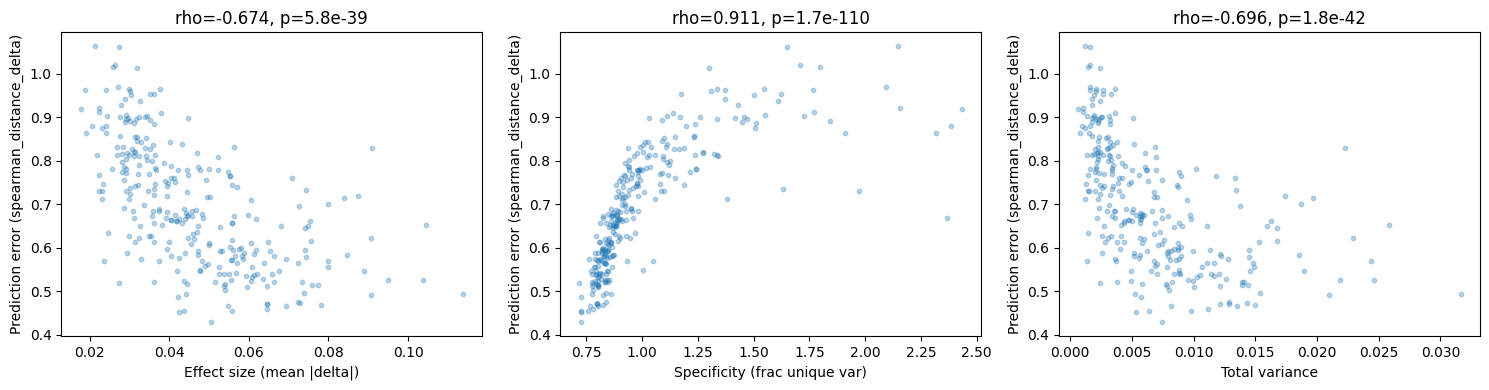

In [11]:
from scipy.stats import spearmanr

results_all = []

for c in gene_perf['dataset'].unique():
    df_temp = gene_perf[(gene_perf['dataset'] == c) & (gene_perf['method'] == 'trainMean')
                        & (gene_perf['deg_rank'] <= 10000)].copy()
    
    # Average across splits
    avg = df_temp.groupby(['perturbation', 'gene']).agg(
        true_delta=('mean_true_delta', 'mean'),
    ).reset_index()
    
    # Gene x perturbation delta matrix
    delta_matrix = avg.pivot(index='gene', columns='perturbation', values='true_delta')
    
    # Gene main effect (alpha_i): average delta across all perturbations
    gene_effect = delta_matrix.mean(axis=1)
    
    records = []
    for pert in delta_matrix.columns:
        col = delta_matrix[pert].dropna()
        gene_eff = gene_effect.loc[col.index]
        
        # Effect size: how strong is this perturbation?
        effect_size = col.abs().mean()
        
        # Residual after removing gene main effect
        residual = col - gene_eff
        
        total_var = col.var()
        resid_var = residual.var()
        
        # Specificity: fraction of variance that is unique to this perturbation
        # High = unique pattern, Low = looks like the average perturbation
        specificity = resid_var / total_var if total_var > 0 else np.nan
        
        records.append({
            'perturbation': pert,
            'dataset': c,
            'effect_size': effect_size,
            'total_var': total_var,
            'specificity': specificity,
            'gene_effect_var': (total_var - resid_var),  # variance explained by alpha_i
        })
    
    results_all.append(pd.DataFrame(records))

pert_features = pd.concat(results_all, ignore_index=True)

# Merge with prediction performance from pivot
pert_features = pert_features.merge(
    pivot.reset_index()[['perturb', 'mean_perf']],
    left_on='perturbation', right_on='perturb', how='inner'
)

# Correlations
print("Spearman correlation with prediction error (mean_perf across cell lines):")
for col in ['effect_size', 'specificity', 'total_var']:
    vals = pert_features.groupby('perturbation')[[col, 'mean_perf']].mean().dropna()
    rho, p = spearmanr(vals[col], vals['mean_perf'])
    print(f"  {col:20s}: rho={rho:.4f}, p={p:.2e}")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, 
    ['effect_size', 'specificity', 'total_var'],
    ['Effect size (mean |delta|)', 'Specificity (frac unique var)', 'Total variance']):
    
    vals = pert_features.groupby('perturbation')[[col, 'mean_perf']].mean()
    ax.scatter(vals[col], vals['mean_perf'], alpha=0.3, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Prediction error (spearman_distance_delta)')
    rho, p = spearmanr(vals[col], vals['mean_perf'])
    ax.set_title(f'rho={rho:.3f}, p={p:.1e}')

plt.tight_layout()
plt.show()



In [10]:
new_metrics

,DataSet,method,split,perturb,DEG,Nstimulated,Nimputed,metric,performance
0,HCT116,CPA,5,AATF,10000,34,34,pearson_distance_raw,0.0069
1,HCT116,CPA,5,AATF,10000,34,34,spearman_distance_raw,0.0295
2,HCT116,CPA,5,AATF,10000,34,34,pearson_distance_delta,0.8990
3,HCT116,CPA,5,AATF,10000,34,34,spearman_distance_delta,0.9419
4,HCT116,CPA,5,AATF,10000,34,34,mean_absolute_error_delta,0.0326
...,...,...,...,...,...,...,...,...,...
115867,rpe1,trainMean,4,ZNF24,10000,49,49,spearman_distance_delta,0.9917
115868,rpe1,trainMean,4,ZNF24,10000,49,49,mean_absolute_error_delta,0.0486
115869,rpe1,trainMean,4,ZNF24,10000,49,49,l1_norm_delta,249.2119
115870,rpe1,trainMean,4,ZNF24,10000,49,49,l2_norm_delta,4.8084


In [46]:
results = method_performance_overview(
    new_metrics[new_metrics.DEG == 1000],
    common_only=True,
    convert_higher_to_lower=True,   # flips ccc_delta to distance
)


Converted higher-is-better metrics to lower-is-better:
  ccc_delta -> ccc_distance_delta (performance = 1 - value)
Filtered to 284 common perturbations across ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']

0. NUMBER OF PERTURBATIONS PER METHOD x CELL LINE
DataSet    HCT116  HEK293T  K562  hepg2  jurkat  rpe1
method                                               
CPA           284      284   284    284     284   284
GEARS         284      284   284    284     284   284
scGPT         284      284   284    284     284   284
trainMean     284      284   284    284     284   284

1. OVERALL MEAN PERFORMANCE (lower = better)
method
trainMean    0.4596
scGPT        0.5046
GEARS        0.5235
CPA          0.5823

2. METHOD x CELL LINE (avg across metric, DEG)
DataSet    HCT116  HEK293T    K562   hepg2  jurkat    rpe1    mean
method                                                            
trainMean  0.4989   0.5034  0.4795  0.4519  0.4744  0.3493  0.4596
scGPT      0.5271   0.5603 

In [15]:
df1 = df[(df.metric.isin(["pearson_distance_delta", "spearman_distance_raw", 
"spearman_distance_delta", "pearson_distance_raw", "mean_absolute_error", "root_mean_squared_error"]))]

#  & 
# (df.method == "trainMean")] # 'mmd', 'edistance', 'sym_kldiv'

Cell lines: ['HCT116', 'HEK293T', 'K562']
Common perturbations: 899

-- mean_absolute_error (n=899) --
  HCT116 vs HEK293T:  Spearman rho=0.7611 (p=8.69e-171)  |  Pearson r=0.7303 (p=1.32e-150)
  HCT116 vs K562:  Spearman rho=0.4076 (p=2.64e-37)  |  Pearson r=0.4255 (p=7.78e-41)
  HEK293T vs K562:  Spearman rho=0.3233 (p=2.60e-23)  |  Pearson r=0.3829 (p=9.00e-33)

-- pearson_distance_delta (n=899) --
  HCT116 vs HEK293T:  Spearman rho=0.3313 (p=1.82e-24)  |  Pearson r=0.3338 (p=7.81e-25)
  HCT116 vs K562:  Spearman rho=0.2738 (p=6.45e-17)  |  Pearson r=0.2895 (p=8.07e-19)
  HEK293T vs K562:  Spearman rho=0.2527 (p=1.45e-14)  |  Pearson r=0.2712 (p=1.28e-16)

-- pearson_distance_raw (n=899) --
  HCT116 vs HEK293T:  Spearman rho=0.8765 (p=5.41e-287)  |  Pearson r=0.6508 (p=2.09e-109)
  HCT116 vs K562:  Spearman rho=0.3262 (p=9.79e-24)  |  Pearson r=0.2032 (p=7.79e-10)
  HEK293T vs K562:  Spearman rho=0.3032 (p=1.43e-20)  |  Pearson r=0.2252 (p=8.50e-12)

-- root_mean_squared_error (n=89

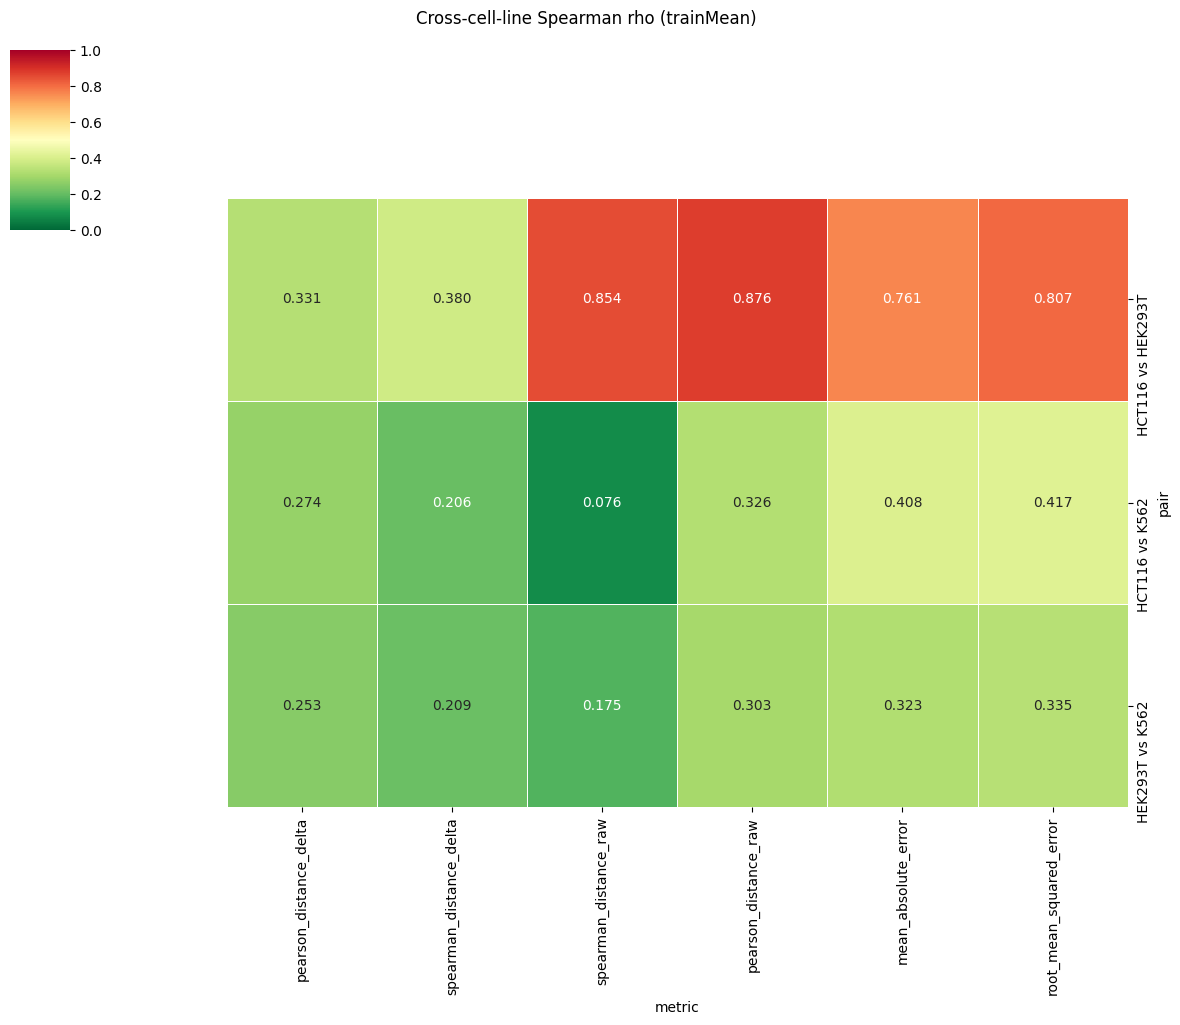

In [99]:
from results_analysis_helper import *

# res1 = crosscell_per_metric(df1[df1.method == "trainMean"])

import matplotlib.pyplot as plt
import seaborn as sns

res1 = crosscell_per_metric(df1[df1.method == "trainMean"])

# Pivot to metric x pair heatmap
heatmap_data = res1.pivot(index='pair', columns='metric', values='spearman_rho')


# fig, ax = plt.subplots(figsize=(12, 10))
# Option 2: cluster but hide dendrogram ticks
g = sns.clustermap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn_r', vmin=0, vmax=1,
                   linewidths=0.5, figsize=(12, 10), method='average')
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.suptitle("Cross-cell-line Spearman rho (trainMean)", y=1.02)
plt.show()

# res2 = crosscell_per_deg(df1)
# res3a = crosscell_per_method(df1)
# res3b = crosscell_per_method_metric(df1)
# res3c = crosscell_per_method_deg(df1)



=== root_mean_squared_error ===
  (using trainMean)
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Kendall's W = 0.6174  (chi2=1048.32, df=283, p=0.00e+00)
  n_perturbations=284, n_cell_lines=6
  Interpretation: strong concordance

=== pearson_distance_delta ===
  (using trainMean)
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Kendall's W = 0.4673  (chi2=793.55, df=283, p=0.00e+00)
  n_perturbations=284, n_cell_lines=6
  Interpretation: moderate concordance

=== spearman_distance_raw ===
  (using trainMean)
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Kendall's W = 0.4532  (chi2=769.46, df=283, p=0.00e+00)
  n_perturbations=284, n_cell_lines=6
  Interpretation: moderate concordance

=== mean_absolute_error ===
  (using trainMean)
Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Kendall's W = 0.6

/hpc/home/hl489/tmp/ipykernel_416879/633145703.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


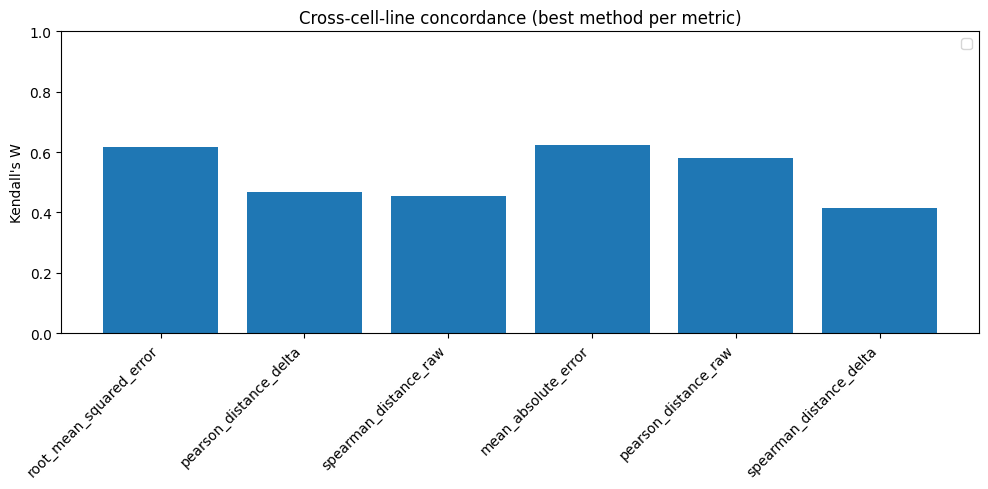

In [18]:


# Variance decomposition per method
# for method in df['method'].unique():

#     print(f"\n=== {method} ===")
#     kendall_w(df[df['method'] == method])
#     variance_decomposition(df[df['method'] == method])

# for metric in df1['metric'].unique():
#     print(f"\n=== {metric} ===")
    
#     kendall_w(df[df['metric'] == metric])

import matplotlib.pyplot as plt

delta_metrics = ['pearson_distance_delta', 'spearman_distance_delta']
w_results = {}

for metric in df1['metric'].unique():
    print(f"\n=== {metric} ===")
    # if metric in delta_metrics:
    #     sub = df[(df['metric'] == metric) & (df['method'] == 'trainMean')]
    #     print("  (using trainMean)")
    # else:
    #     sub = df[(df['metric'] == metric) & (df['method'] == 'CPA')]
    #     print("  (using CPA)")
    sub = df1[(df1['metric'] == metric) & (df1['method'] == 'trainMean')]
    print("  (using trainMean)")

    res = kendall_w(sub)
    w_results[metric] = res['W']

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
metrics = list(w_results.keys())
ws = [w_results[m] for m in metrics]
bars = ax.bar(range(len(metrics)), ws)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_ylabel("Kendall's W")
ax.set_ylim(0, 1)
# ax.axhline(0.3, color='gray', linestyle='--', alpha=0.5, label='weak/moderate')
# ax.axhline(0.6, color='gray', linestyle=':', alpha=0.5, label='moderate/strong')
ax.legend()
ax.set_title("Cross-cell-line concordance (best method per metric)")
plt.tight_layout()
plt.show()




In [19]:
from results_analysis_helper import *

pivot = perturbation_analysis(df1, method="trainMean", metric="spearman_distance_delta", deg=2000, top_n=30, agg_func='median')



Cell lines: ['HCT116', 'HEK293T', 'K562', 'hepg2', 'jurkat', 'rpe1']
Common perturbations: 284
Method=trainMean, Metric=spearman_distance_delta, DEG=2000
Lower = better | n=284 common perturbations

TOP 30 BEST PREDICTED (lowest spearman_distance_delta)
DataSet  HCT116  HEK293T    K562   hepg2  jurkat    rpe1  mean_perf
perturb                                                            
ELL      0.5635   0.6089  0.5140  0.2814  0.2706  0.0570     0.3826
GTF2E2   0.8526   0.5700  0.3800  0.2575  0.2270  0.1308     0.4030
POLR2H   0.3669   0.5066  0.4998  0.2256  0.6072  0.2464     0.4088
MCM3     0.5634   0.5972  0.4622  0.2905  0.5363  0.0805     0.4217
CSE1L    0.5479   0.5922  0.4583  0.3336  0.4674  0.1327     0.4220
ERCC2    0.6123   0.5208  0.3381  0.5444  0.3297  0.2050     0.4250
POLR2A   0.4745   0.5385  0.4272  0.1941  0.4652  0.4514     0.4252
PAF1     0.6901   0.6108  0.5171  0.1994  0.3593  0.2030     0.4300
RBM25    0.4726   0.7015  0.4939  0.3463  0.4099  0.1564     0.430

In [71]:
# from scipy.stats import hypergeom
# from matplotlib.colors import ListedColormap

# res = topk_overlap(df1[df1['metric'] == 'spearman_distance_delta'], k_values=[57, 71, 94])

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# cmap = ListedColormap(['#f0f0f0', '#d62728'])  # gray = NS, red = significant

# for col, k_val in enumerate([57, 71, 94]):
#     for row, direction in enumerate(['hardest', 'easiest']):
#         ax = axes[row, col]
#         sub = res[(res['k'] == k_val) & (res['direction'] == direction)]
        
#         cell_lines = sorted(set(
#             [p.split(' vs ')[0] for p in sub['pair']] + 
#             [p.split(' vs ')[1] for p in sub['pair']]
#         ))
        
#         sig_mat = pd.DataFrame(np.nan, index=cell_lines, columns=cell_lines)
#         annot = pd.DataFrame('', index=cell_lines, columns=cell_lines)
#         n_perturbs = k_val ** 2 / sub['expected_random'].iloc[0]
        
#         for _, r in sub.iterrows():
#             ds1, ds2 = r['pair'].split(' vs ')
#             p_val = hypergeom.sf(r['intersection'] - 1, int(n_perturbs), k_val, k_val)
#             is_sig = 1 if p_val < 0.01 else 0
#             sig_mat.loc[ds1, ds2] = is_sig
#             sig_mat.loc[ds2, ds1] = is_sig
#             label = f"{int(r['intersection'])}/{k_val}\np={p_val:.1e}"
#             annot.loc[ds1, ds2] = label
#             annot.loc[ds2, ds1] = label
        
#         for cl in cell_lines:
#             sig_mat.loc[cl, cl] = np.nan
#             annot.loc[cl, cl] = f'{k_val}/{k_val}'
        
#         sns.heatmap(sig_mat.astype(float), annot=annot, fmt='', cmap=cmap,
#                     vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar=False)
#         expected = sub['expected_random'].iloc[0]
#         ax.set_title(f'k={k_val}, {direction}\n(expected random: {expected:.1f}, red = p<0.01)')

# plt.tight_layout()
# plt.show()


Metric: spearman_distance_raw
284 common perturbations across 6 cell lines

--- Per-cell-line stats ---
           mean  median     std      cv
DataSet                                
HEK293T  0.0540  0.0428  0.0436  0.8075
K562     0.0589  0.0447  0.0465  0.7892
jurkat   0.0831  0.0694  0.0521  0.6267
HCT116   0.0940  0.0794  0.0587  0.6246
hepg2    0.0946  0.0811  0.0635  0.6717
rpe1     0.0993  0.0863  0.0603  0.6072

--- Spearman correlation of error vectors ---
DataSet  HCT116  HEK293T   K562  hepg2  jurkat   rpe1
DataSet                                              
HCT116    1.000    0.801  0.041  0.069   0.008  0.104
HEK293T   0.801    1.000  0.198  0.161   0.137  0.210
K562      0.041    0.198  1.000  0.365   0.446  0.409
hepg2     0.069    0.161  0.365  1.000   0.563  0.618
jurkat    0.008    0.137  0.446  0.563   1.000  0.616
rpe1      0.104    0.210  0.409  0.618   0.616  1.000

--- Pairwise correlation distance ---
         HCT116  HEK293T   K562  hepg2  jurkat   rpe1
HCT1

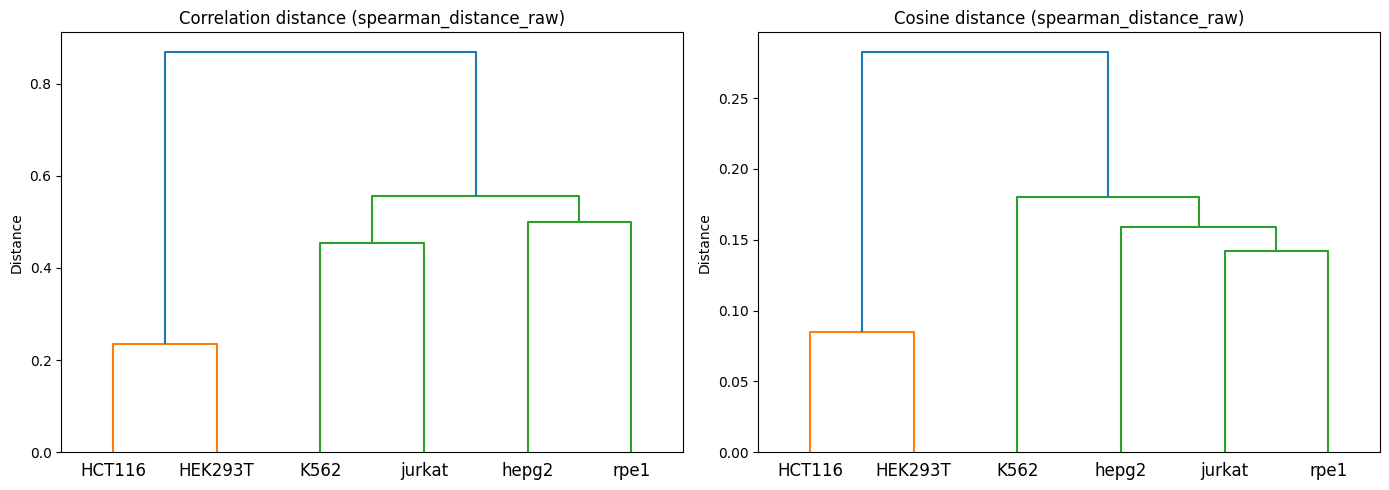

In [25]:
from results_analysis_helper import *
res = cellline_clustering(df, metric_name='spearman_distance_raw')
